In [97]:
import gc
import os
import math
import numpy as np
import pandas as pd
from numba import njit
from numpy import sqrt, sin, cos, pi, zeros
from numpy.random import randn, rand, uniform, normal
from scipy.linalg import hadamard
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Activation, LSTM, Dropout, RepeatVector, TimeDistributed, Embedding, Reshape, Dot, Concatenate
from tensorflow.keras.layers import GRU, SpatialDropout1D, Conv1D, GlobalMaxPooling1D,Multiply, Lambda, Softmax, Flatten, BatchNormalization, Bidirectional, dot, concatenate
from tensorflow.keras.layers import AdditiveAttention, Attention
from tensorflow.keras.activations import relu
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras import backend
from tensorflow.keras.utils import plot_model
from tensorflow.keras.metrics import MeanSquaredError
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

print("Tensorflow version " + tf.__version__)
AUTO = tf.data.experimental.AUTOTUNE


Tensorflow version 2.9.1


In [11]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection. No parameters necessary if TPU_NAME environment variable is set. On Kaggle this is always the case.
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy() # default distribution strategy in Tensorflow. Works on CPU and single GPU.

print("REPLICAS: ", strategy.num_replicas_in_sync)

REPLICAS:  1


In [98]:
MIXED_PRECISION = False
XLA_ACCELERATE = True

if MIXED_PRECISION:
    from tensorflow.keras.mixed_precision import experimental as mixed_precision
    if tpu: policy = tf.keras.mixed_precision.experimental.Policy('mixed_bfloat16')
    else: policy = tf.keras.mixed_precision.experimental.Policy('mixed_float16')
    mixed_precision.set_policy(policy)
    print('Mixed precision enabled')

if XLA_ACCELERATE:
    tf.config.optimizer.set_jit(True)
    print('Accelerated Linear Algebra enabled')

Accelerated Linear Algebra enabled


In [192]:
lotto = pd.read_csv('C:\\Users\\cherrywu\\Documents\\Npower\\lottery\\649\\649.csv', index_col = 'Date')
print(lotto)

           NUMBER DRAWN 1  NUMBER DRAWN 2  NUMBER DRAWN 3  NUMBER DRAWN 4  \
Date                                                                        
1982/6/12               3              11              12              14   
1982/6/19               8              33              36              37   
1982/6/26               1               6              23              24   
1982/7/3                3               9              10              13   
1982/7/10               5              14              21              31   
...                   ...             ...             ...             ...   
2022/7/30               9              21              22              27   
2022/8/3               10              15              24              27   
2022/8/6               10              18              21              31   
2022/8/10               8               9              36              38   
2022/8/13               5               8              13              35   

In [193]:
data = lotto.values - 1
train = data[:-400]
test = data[-400:]

w = 10
X_train = []
y_train = []
for i in range(w, len(train)):
    X_train.append(train[i - w: i, :])
    y_train.append(train[i])
X_train, y_train = np.array(X_train), np.array(y_train)
inputs = data[data.shape[0] - test.shape[0] - w:]
X_test = []
for i in range(w, inputs.shape[0]):
    X_test.append(inputs[i - w: i, :])
X_test = np.array(X_test)
y_test = test

In [194]:
print(data.shape)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4024, 7)
(3614, 10, 7)
(3614, 7)
(400, 10, 7)
(400, 7)


In [117]:
embed_dim = (59 // 2) + 1
dropout_rate = 0.5
spatial_dropout_rate = 0.5
steps_before = w
steps_after = 7
feature_count = embed_dim * 7
hidden_neurons = [64, 32] 
bidirectional = True 
attention_style = 'Bahdanau'

In [102]:
with strategy.scope():
    
    inp0 = Input(shape = (w, X_train.shape[2]))
    
    # Embed 59 categories into a 30-dimension continuous-number vector for each ball
    inp1 = Lambda(lambda x: x[:, :, 0])(inp0)
    inp1 = Embedding(59, embed_dim)(inp1)
    inp1 = SpatialDropout1D(spatial_dropout_rate)(inp1)
    
    inp2 = Lambda(lambda x: x[:, :, 1])(inp0)
    inp2 = Embedding(59, embed_dim)(inp2)
    inp2 = SpatialDropout1D(spatial_dropout_rate)(inp2)
    inp3 = Lambda(lambda x: x[:, :, 2])(inp0)
    inp3 = Embedding(59, embed_dim)(inp3)
    inp3 = SpatialDropout1D(spatial_dropout_rate)(inp3)
    
    inp4 = Lambda(lambda x: x[:, :, 3])(inp0)
    inp4 = Embedding(59, embed_dim)(inp4)
    inp4 = SpatialDropout1D(spatial_dropout_rate)(inp4)
    
    inp5 = Lambda(lambda x: x[:, :, 4])(inp0)
    inp5 = Embedding(59, embed_dim)(inp5)
    inp5 = SpatialDropout1D(spatial_dropout_rate)(inp5)    
    
    inp6 = Lambda(lambda x: x[:, :, 5])(inp0)
    inp6 = Embedding(59, embed_dim)(inp6)
    inp6 = SpatialDropout1D(spatial_dropout_rate)(inp6)
    inp7 = Lambda(lambda x: x[:, :, 6])(inp0)
    inp7 = Embedding(59, embed_dim)(inp7)
    inp7 = SpatialDropout1D(spatial_dropout_rate)(inp7)
    
    inp = Concatenate()([inp1, inp2, inp3, inp4, inp5, inp6, inp7])
    
    # Seq2Seq model with attention or bidirectional encoder
    
    num_layers = len(hidden_neurons)
    
    sh_list, h_list, c_list = [inp], [], []
    if bidirectional:
        
        for i in range(num_layers):
    
            sh, fh, fc, bh, bc = Bidirectional(LSTM(hidden_neurons[i],
                                                    dropout = dropout_rate, 
                                                    return_state = True, 
                                                    return_sequences = True))(sh_list[-1])
        
            h = Concatenate()([fh, bh])
            c = Concatenate()([fc, bc]) 

            sh_list.append(sh)
            h_list.append(h)
            c_list.append(c)
        
    else:
    
        for i in range(num_layers):

            sh, h, c = LSTM(hidden_neurons[i], 
                            dropout = dropout_rate,
                            return_state = True, 
                            return_sequences = True)(sh_list[-1])

            sh_list.append(sh)
            h_list.append(h)
            c_list.append(c)
    
    decoder = RepeatVector(steps_after)(h_list[-1])
    
    if bidirectional:
        
        decoder_hidden_neurons = [hn * 2 for hn in hidden_neurons]
        
    else:
        
        decoder_hidden_neurons = hidden_neurons
    
    for i in range(num_layers):
        
        decoder = LSTM(decoder_hidden_neurons[i],
                       dropout = dropout_rate, 
                       return_sequences = True)(decoder, initial_state = [h_list[i], c_list[i]])
       
    if attention_style == 'Bahdanau':
        
        context = AdditiveAttention(dropout = dropout_rate)([decoder, sh_list[-1]])
        
        decoder = concatenate([context, decoder])
    elif attention_style == 'Luong':
        
        context = Attention(dropout = dropout_rate)([decoder, sh_list[-1]])
        
        decoder = concatenate([context, decoder])
    
    out = Dense(59, activation = 'softmax')(decoder)

    model = Model(inputs = inp0, outputs = out)
    
    sparse_top_k = tf.keras.metrics.SparseTopKCategoricalAccuracy(k = 5, name = 'sparse_top_k')

    model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = [sparse_top_k])

In [21]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 10, 7)]      0           []                               
                                                                                                  
 lambda (Lambda)                (None, 10)           0           ['input_1[0][0]']                
                                                                                                  
 lambda_1 (Lambda)              (None, 10)           0           ['input_1[0][0]']                
                                                                                                  
 lambda_2 (Lambda)              (None, 10)           0           ['input_1[0][0]']                
                                                                                              

                                                                  'bidirectional[0][4]']          
                                                                                                  
 lstm_2 (LSTM)                  (None, 7, 128)       98816       ['repeat_vector[0][0]',          
                                                                  'concatenate_1[0][0]',          
                                                                  'concatenate_2[0][0]']          
                                                                                                  
 concatenate_4 (Concatenate)    (None, 64)           0           ['bidirectional_1[0][2]',        
                                                                  'bidirectional_1[0][4]']        
                                                                                                  
 lstm_3 (LSTM)                  (None, 7, 64)        49408       ['lstm_2[0][0]',                 
          

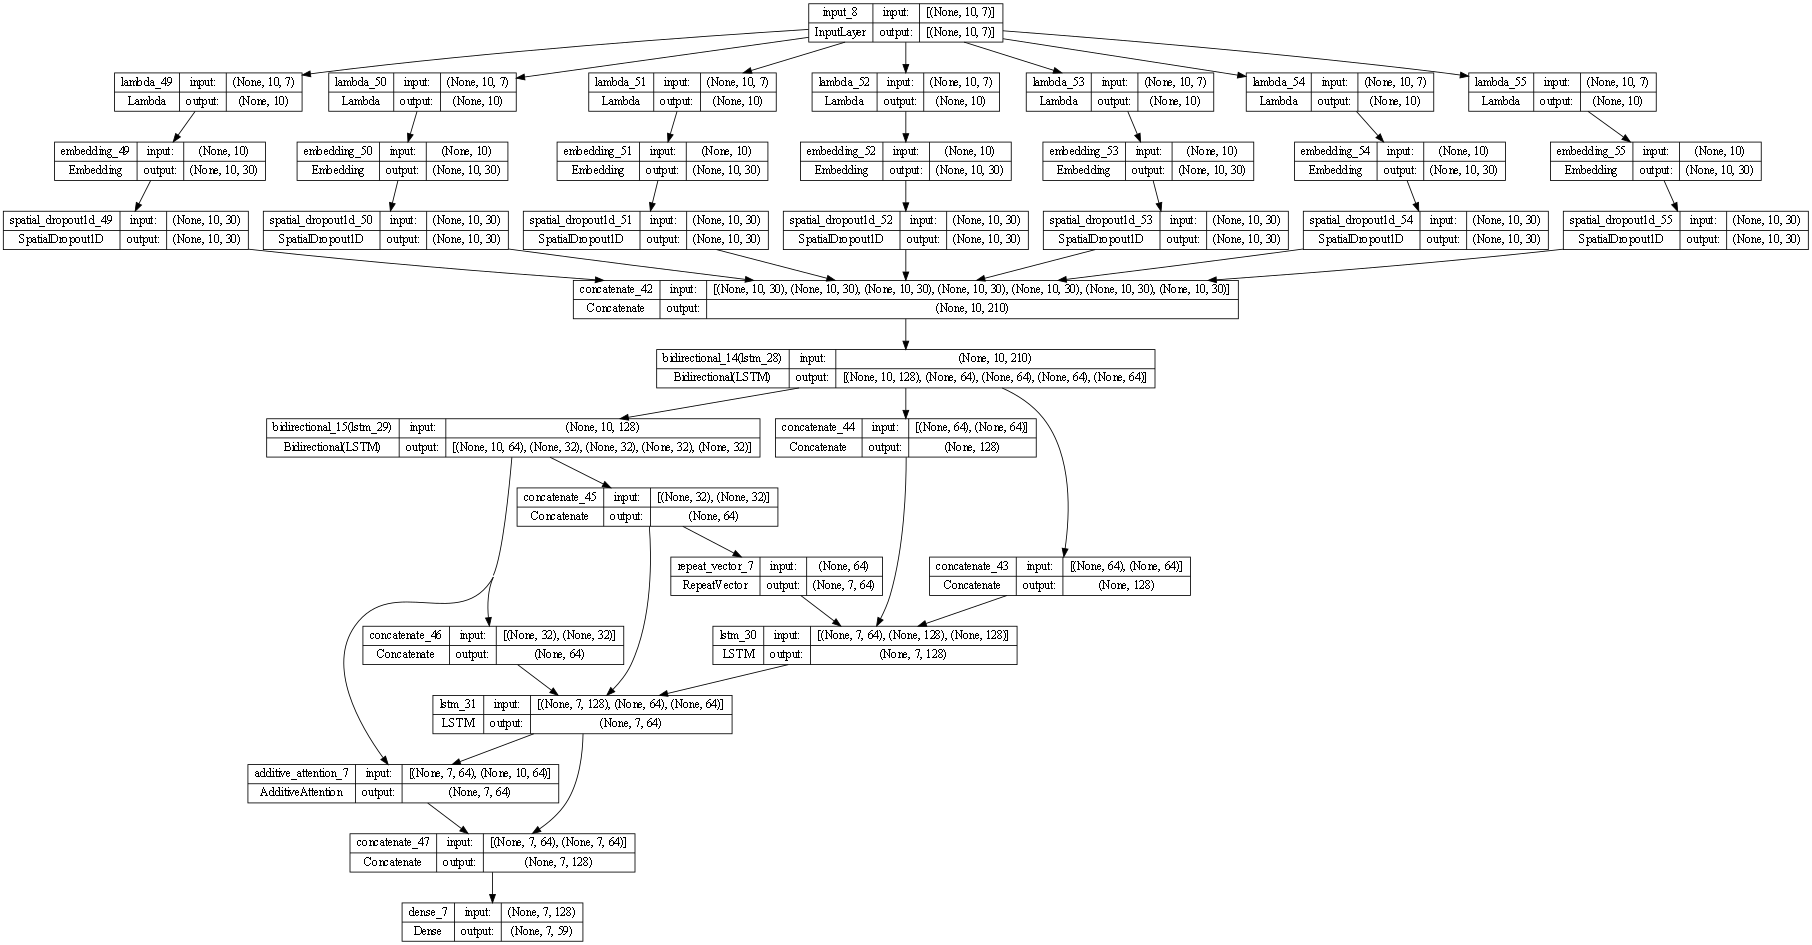

In [103]:
plot_model(model, show_shapes = True, show_layer_names = True, rankdir = 'TB', dpi = 60)

In [109]:
class CosineAnnealingScheduler(callbacks.Callback):
    """Cosine annealing scheduler.
    """

    def __init__(self, T_max, eta_max, eta_min = 0, verbose = 0):
        super(CosineAnnealingScheduler, self).__init__()
        self.T_max = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs = None):
        if not hasattr(self.model.optimizer, 'lr'):
            raise ValueError('Optimizer must have a "lr" attribute.')
        lr = self.eta_min + (self.eta_max - self.eta_min) * (1 + math.cos(math.pi * epoch / self.T_max)) / 2
        backend.set_value(self.model.optimizer.lr, lr)
        if self.verbose > 0:
            print('\nEpoch %05d: CosineAnnealingScheduler setting learning '
                  'rate to %s.' % (epoch + 1, lr))

    def on_epoch_end(self, epoch, logs = None):
        logs = logs or {}
        logs['lr'] = backend.get_value(self.model.optimizer.lr)


In [195]:
EPOCHS = 200
BATCH_SIZE = 32
LR_MAX = 1e-4
LR_MIN = 1e-5

cas = CosineAnnealingScheduler(EPOCHS, LR_MAX, LR_MIN)

ckp = callbacks.ModelCheckpoint('best_model.hdf5', monitor = 'val_sparse_top_k', verbose = 0, 
                                save_best_only = True, save_weights_only = False, mode = 'max')
history = model.fit(X_train, y_train, 
                    validation_data = (X_test, y_test), 
                    callbacks = [ckp, cas], 
                    epochs = EPOCHS, 
                    batch_size = BATCH_SIZE, 
                    verbose = 2)

hist = pd.DataFrame(history.history)

Epoch 1/200
113/113 - 11s - loss: 3.4951 - sparse_top_k: 0.2769 - val_loss: 3.4477 - val_sparse_top_k: 0.2768 - lr: 1.0000e-04 - 11s/epoch - 100ms/step
Epoch 2/200
113/113 - 11s - loss: 3.4006 - sparse_top_k: 0.2878 - val_loss: 3.4013 - val_sparse_top_k: 0.2839 - lr: 9.9994e-05 - 11s/epoch - 100ms/step
Epoch 3/200
113/113 - 11s - loss: 3.3725 - sparse_top_k: 0.2928 - val_loss: 3.3832 - val_sparse_top_k: 0.2854 - lr: 9.9978e-05 - 11s/epoch - 99ms/step
Epoch 4/200
113/113 - 11s - loss: 3.3602 - sparse_top_k: 0.2939 - val_loss: 3.3725 - val_sparse_top_k: 0.2821 - lr: 9.9950e-05 - 11s/epoch - 97ms/step
Epoch 5/200
113/113 - 11s - loss: 3.3501 - sparse_top_k: 0.2964 - val_loss: 3.3683 - val_sparse_top_k: 0.2889 - lr: 9.9911e-05 - 11s/epoch - 98ms/step
Epoch 6/200
113/113 - 11s - loss: 3.3478 - sparse_top_k: 0.2975 - val_loss: 3.3654 - val_sparse_top_k: 0.2900 - lr: 9.9861e-05 - 11s/epoch - 99ms/step
Epoch 7/200
113/113 - 11s - loss: 3.3453 - sparse_top_k: 0.2941 - val_loss: 3.3633 - val_spa

Epoch 55/200
113/113 - 12s - loss: 3.3060 - sparse_top_k: 0.3148 - val_loss: 3.3553 - val_sparse_top_k: 0.2907 - lr: 8.4759e-05 - 12s/epoch - 102ms/step
Epoch 56/200
113/113 - 12s - loss: 3.3064 - sparse_top_k: 0.3170 - val_loss: 3.3578 - val_sparse_top_k: 0.2896 - lr: 8.4225e-05 - 12s/epoch - 103ms/step
Epoch 57/200
113/113 - 12s - loss: 3.3032 - sparse_top_k: 0.3173 - val_loss: 3.3551 - val_sparse_top_k: 0.2900 - lr: 8.3684e-05 - 12s/epoch - 104ms/step
Epoch 58/200
113/113 - 12s - loss: 3.3055 - sparse_top_k: 0.3157 - val_loss: 3.3568 - val_sparse_top_k: 0.2900 - lr: 8.3136e-05 - 12s/epoch - 104ms/step
Epoch 59/200
113/113 - 13s - loss: 3.3025 - sparse_top_k: 0.3177 - val_loss: 3.3563 - val_sparse_top_k: 0.2971 - lr: 8.2581e-05 - 13s/epoch - 113ms/step
Epoch 60/200
113/113 - 11s - loss: 3.3059 - sparse_top_k: 0.3143 - val_loss: 3.3575 - val_sparse_top_k: 0.2825 - lr: 8.2019e-05 - 11s/epoch - 99ms/step
Epoch 61/200
113/113 - 11s - loss: 3.3008 - sparse_top_k: 0.3163 - val_loss: 3.3564

Epoch 109/200
113/113 - 12s - loss: 3.2836 - sparse_top_k: 0.3253 - val_loss: 3.3603 - val_sparse_top_k: 0.2925 - lr: 4.9360e-05 - 12s/epoch - 103ms/step
Epoch 110/200
113/113 - 11s - loss: 3.2801 - sparse_top_k: 0.3272 - val_loss: 3.3581 - val_sparse_top_k: 0.2907 - lr: 4.8659e-05 - 11s/epoch - 101ms/step
Epoch 111/200
113/113 - 11s - loss: 3.2841 - sparse_top_k: 0.3265 - val_loss: 3.3576 - val_sparse_top_k: 0.2932 - lr: 4.7960e-05 - 11s/epoch - 101ms/step
Epoch 112/200
113/113 - 12s - loss: 3.2846 - sparse_top_k: 0.3272 - val_loss: 3.3575 - val_sparse_top_k: 0.2961 - lr: 4.7263e-05 - 12s/epoch - 105ms/step
Epoch 113/200
113/113 - 12s - loss: 3.2847 - sparse_top_k: 0.3247 - val_loss: 3.3562 - val_sparse_top_k: 0.2957 - lr: 4.6568e-05 - 12s/epoch - 106ms/step
Epoch 114/200
113/113 - 12s - loss: 3.2816 - sparse_top_k: 0.3262 - val_loss: 3.3578 - val_sparse_top_k: 0.2918 - lr: 4.5875e-05 - 12s/epoch - 107ms/step
Epoch 115/200
113/113 - 12s - loss: 3.2814 - sparse_top_k: 0.3255 - val_loss

Epoch 163/200
113/113 - 12s - loss: 3.2754 - sparse_top_k: 0.3300 - val_loss: 3.3606 - val_sparse_top_k: 0.2929 - lr: 1.7781e-05 - 12s/epoch - 102ms/step
Epoch 164/200
113/113 - 12s - loss: 3.2709 - sparse_top_k: 0.3312 - val_loss: 3.3605 - val_sparse_top_k: 0.2946 - lr: 1.7389e-05 - 12s/epoch - 104ms/step
Epoch 165/200
113/113 - 12s - loss: 3.2729 - sparse_top_k: 0.3314 - val_loss: 3.3605 - val_sparse_top_k: 0.2921 - lr: 1.7005e-05 - 12s/epoch - 104ms/step
Epoch 166/200
113/113 - 12s - loss: 3.2702 - sparse_top_k: 0.3341 - val_loss: 3.3609 - val_sparse_top_k: 0.2943 - lr: 1.6631e-05 - 12s/epoch - 103ms/step
Epoch 167/200
113/113 - 12s - loss: 3.2724 - sparse_top_k: 0.3309 - val_loss: 3.3601 - val_sparse_top_k: 0.2925 - lr: 1.6267e-05 - 12s/epoch - 103ms/step
Epoch 168/200
113/113 - 12s - loss: 3.2714 - sparse_top_k: 0.3296 - val_loss: 3.3600 - val_sparse_top_k: 0.2921 - lr: 1.5912e-05 - 12s/epoch - 103ms/step
Epoch 169/200
113/113 - 12s - loss: 3.2744 - sparse_top_k: 0.3283 - val_loss

0.2978571355342865


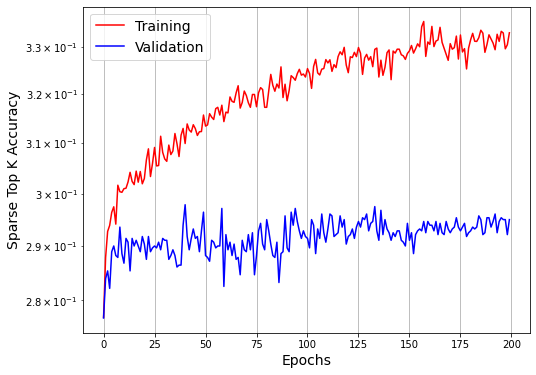

In [196]:
print(hist['val_sparse_top_k'].max())

plt.figure(figsize = (8, 6))
plt.semilogy(hist['sparse_top_k'], '-r', label = 'Training')
plt.semilogy(hist['val_sparse_top_k'], '-b', label = 'Validation')
plt.ylabel('Sparse Top K Accuracy', fontsize = 14)
plt.xlabel('Epochs', fontsize = 14)
plt.legend(fontsize = 14)
plt.grid()
plt.show()

In [197]:
model.load_weights('best_model.hdf5')
pred = model.predict(X_test)
pred = np.argmax(pred, axis = 2)

13/13 [==============================] - 3s 35ms/step


In [198]:
for i in range(y_test.shape[0]):
    print('Prediction:\t', pred[i] + 1)
    print('GoundTruth:\t', y_test[i] + 1)
    print('-' * 40)

Prediction:	 [ 1 15 25 36 43 49  5]
GoundTruth:	 [10 32 37 45 46 47  6]
----------------------------------------
Prediction:	 [ 1 15 25 36 43 49  5]
GoundTruth:	 [ 4 12 16 25 30 31  8]
----------------------------------------
Prediction:	 [ 1 15 25 36 43 49  5]
GoundTruth:	 [ 4 11 19 23 24 34 20]
----------------------------------------
Prediction:	 [ 4 15 25 36 38 49  5]
GoundTruth:	 [10 18 21 29 35 37 24]
----------------------------------------
Prediction:	 [ 1 15 25 31 40 49 11]
GoundTruth:	 [ 4  9 11 15 25 27  5]
----------------------------------------
Prediction:	 [ 1 12 25 32 40 49 11]
GoundTruth:	 [ 7  8 24 32 42 48 45]
----------------------------------------
Prediction:	 [ 1  6 21 25 40 48 11]
GoundTruth:	 [ 2 10 13 16 31 43  8]
----------------------------------------
Prediction:	 [ 4 12 25 31 40 48 11]
GoundTruth:	 [ 6  9 16 20 31 41 49]
----------------------------------------
Prediction:	 [ 4 17 25 31 40 48 11]
GoundTruth:	 [ 5 10 20 23 35 42 44]
------------------------

GoundTruth:	 [15 16 17 30 36 40 34]
----------------------------------------
Prediction:	 [ 2 12 23 31 42 49  5]
GoundTruth:	 [ 3  7  8 12 37 40 41]
----------------------------------------
Prediction:	 [ 2 12 22 34 43 49  5]
GoundTruth:	 [12 13 19 35 42 47 28]
----------------------------------------
Prediction:	 [ 2 12 19 34 40 49  5]
GoundTruth:	 [23 31 34 38 39 41 12]
----------------------------------------
Prediction:	 [ 2 12 18 31 40 49  5]
GoundTruth:	 [ 5 16 19 24 28 34  4]
----------------------------------------
Prediction:	 [ 1 12 18 28 40 49  9]
GoundTruth:	 [ 4  6 12 23 36 47 18]
----------------------------------------
Prediction:	 [ 1 12 22 31 37 49  5]
GoundTruth:	 [ 7 13 32 38 39 48 23]
----------------------------------------
Prediction:	 [ 1  8 18 31 40 49 16]
GoundTruth:	 [15 18 23 32 38 47 19]
----------------------------------------
Prediction:	 [ 1  8 18 28 40 49  8]
GoundTruth:	 [14 18 27 33 34 39 49]
----------------------------------------
Prediction:	 [ 1  8

In [199]:
X_latest = X_test[-1][1:]
X_latest = np.concatenate([X_latest, y_test[-1].reshape(1, 7)], axis = 0)
X_latest = X_latest.reshape(1, X_latest.shape[0], X_latest.shape[1])
print(X_latest + 1)

[[[13 18 19 21 35 40 29]
  [ 8 19 23 34 37 44 21]
  [ 1 15 17 25 26 40 39]
  [ 6 23 24 26 39 42 21]
  [ 6 19 29 42 45 49 21]
  [ 9 21 22 27 35 47 31]
  [10 15 24 27 42 46 36]
  [10 18 21 31 34 48  9]
  [ 8  9 36 38 44 45 29]
  [ 5  8 13 35 37 40  3]]]


In [200]:
def beam_search_decoder(data, k, replace = True):
    sequences = [[list(), 0.0]]
    # walk over each step in sequence
    for row in data:
        all_candidates = list()
        # expand each current candidate
        for i in range(len(sequences)):
            seq, score = sequences[i]
            best_k = np.argsort(row)[-k:]
            for j in best_k:
                candidate = [seq + [j], score + math.log(row[j])]
                if replace:
                    all_candidates.append(candidate)
                elif (replace == False) and (len(set(candidate[0])) == len(candidate[0])):
                    all_candidates.append(candidate)
        # order all candidates by score
        ordered = sorted(all_candidates, key = lambda tup:tup[1], reverse = True)
        # select k best
        sequences = ordered[:k]
    return sequences

In [202]:
pred_latest = model.predict(X_latest)
pred_latest = np.squeeze(pred_latest)
pred_latest_greedy = np.argmax(pred_latest, axis = 1)
print(pred_latest_greedy + 1)

1/1 [==============================] - 0s 27ms/step
[ 2 12 21 31 43 49  5]


In [203]:
beam_width = 10
replace = True

result = beam_search_decoder(pred_latest, beam_width, replace)
print('Beam Width:\t', beam_width)
print('Replace:\t', replace)
print('-' * 85)
for seq in result:
    print('Prediction: ', np.array(seq[0]) + 1, '\tLog Likelihood: ', seq[1])

Beam Width:	 10
Replace:	 True
-------------------------------------------------------------------------------------
Prediction:  [ 2 12 21 31 43 49  5] 	Log Likelihood:  -19.13677325411415
Prediction:  [ 2 12 21 31 39 49  5] 	Log Likelihood:  -19.14497697977338
Prediction:  [ 2 12 21 31 43 48  5] 	Log Likelihood:  -19.145437423775494
Prediction:  [ 2 12 21 31 40 49  5] 	Log Likelihood:  -19.14589085570512
Prediction:  [ 2 12 21 31 39 48  5] 	Log Likelihood:  -19.153641149434723
Prediction:  [ 2 12 21 31 40 48  5] 	Log Likelihood:  -19.154555025366463
Prediction:  [ 3 12 21 31 43 49  5] 	Log Likelihood:  -19.16814246847521
Prediction:  [ 3 12 21 31 39 49  5] 	Log Likelihood:  -19.17634619413444
Prediction:  [ 3 12 21 31 43 48  5] 	Log Likelihood:  -19.176806638136554
Prediction:  [ 3 12 21 31 40 49  5] 	Log Likelihood:  -19.17726007006618


In [204]:
beam_width = 10
replace = False

result = beam_search_decoder(pred_latest, beam_width, replace)
print('Beam Width:\t', beam_width)
print('Replace:\t', replace)
print('-' * 85)
for seq in result:
    print('Prediction: ', np.array(seq[0]) + 1, '\tLog Likelihood: ', seq[1])

Beam Width:	 10
Replace:	 False
-------------------------------------------------------------------------------------
Prediction:  [ 2 12 21 31 43 49  5] 	Log Likelihood:  -19.13677325411415
Prediction:  [ 2 12 21 31 39 49  5] 	Log Likelihood:  -19.14497697977338
Prediction:  [ 2 12 21 31 43 48  5] 	Log Likelihood:  -19.145437423775494
Prediction:  [ 2 12 21 31 40 49  5] 	Log Likelihood:  -19.14589085570512
Prediction:  [ 2 12 21 31 39 48  5] 	Log Likelihood:  -19.153641149434723
Prediction:  [ 2 12 21 31 40 48  5] 	Log Likelihood:  -19.154555025366463
Prediction:  [ 3 12 21 31 43 49  5] 	Log Likelihood:  -19.16814246847521
Prediction:  [ 3 12 21 31 39 49  5] 	Log Likelihood:  -19.17634619413444
Prediction:  [ 3 12 21 31 43 48  5] 	Log Likelihood:  -19.176806638136554
Prediction:  [ 3 12 21 31 40 49  5] 	Log Likelihood:  -19.17726007006618


In [184]:
inp0

<KerasTensor: shape=(None, 10, 7) dtype=float32 (created by layer 'input_8')>